<a href="https://colab.research.google.com/github/hamnasz/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran/blob/main/SI26_Week4_humna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Fine-Tune TrOCR on the Urdu OCR Dataset

This picks up where Week 3 left off: `labels.csv` and the generated images from Week 3 get fine-tuned into `microsoft/trocr-base-printed` (Microsoft's pretrained OCR model), then evaluated on a held-out test set.

**Before running anything:** `Runtime > Change runtime type > GPU`. CPU training will run but takes hours instead of minutes.

A note on the attached `TensorFlow_with_GPU.ipynb`: that notebook's GPU-connectivity check is TensorFlow-specific (`tf.test.gpu_device_name()`). This project's stack is PyTorch + Hugging Face Transformers (as in the Week 4 handout), so the equivalent check below uses `torch.cuda.is_available()` instead — same idea, different library. Mixing TensorFlow calls into a PyTorch pipeline wouldn't do anything useful here, so it isn't used directly.

**What follows the official handout, and what's added on top:**
- Steps 1–4 below match the Week 4 handout's structure and step numbers.
- **Step 0** is new — it isn't in the handout, but a fresh Colab runtime starts empty, so it has to exist to reconnect to Week 3's data.
- Sections marked **Extra** are additions beyond the handout: a training-loss chart, Character/Word Error Rate alongside exact-match accuracy, automatic extraction of the worst predictions, a visual grid of sample predictions, and per-epoch checkpointing to Google Drive with automatic resume.
- Three real bugs get fixed along the way (verified in a sandboxed test against `transformers==4.57.6`, the version pinned in Week 3): `from transformers import AdamW` no longer exists in this version and raises `ImportError` — `torch.optim.AdamW` is the fix; the labels Week 3 produced pad with the literal pad-token id instead of `-100`, so the loss function was never actually ignoring padding — fixed in the Dataset class below; and the handout's model name has a dropped hyphen (`trocr-baseprinted`) — corrected to `trocr-base-printed` to match Week 3 and the handout's own Sources section.


## Step 0: Reconnect to Your Week 3 Dataset

*(Not in the official handout.)* Week 3 ran in a GitHub Codespace and built up `labels.csv` plus generated images inside your repo. A fresh Colab runtime starts with an empty filesystem, so this cell gets that data back before anything else can run. Pick **one** of the two options below.

In [1]:
import os
import pandas as pd

# OPTION A — clone your GitHub repo (use this if labels.csv + images are committed/pushed).
REPO_URL = "https://github.com/hamnasz/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran.git"

if not os.path.isdir("repo"):
    !git clone {REPO_URL} repo
else:
    print("repo/ already exists, skipping clone")

DATA_DIR = "repo/SI26-Week1/data"

# OPTION B — mount Google Drive (active). labels.csv + images live directly under this folder.
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/SI26-Week4"

LABELS_PATH = os.path.join(DATA_DIR, "labels.csv")
print(f"Found labels.csv with {len(pd.read_csv(LABELS_PATH))} rows at {LABELS_PATH}")

Cloning into 'repo'...
remote: Enumerating objects: 13278, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 13278 (delta 18), reused 26 (delta 10), pack-reused 13241 (from 2)
Receiving objects: 100% (13278/13278), 344.58 MiB | 24.10 MiB/s, done.
Resolving deltas: 100% (739/739), done.
Found labels.csv with 263 rows at repo/SI26-Week1/data/labels.csv


## Step 1: Load the Pretrained TrOCR Model

TrOCR combines a vision encoder (reads the image) with a text decoder (outputs characters). This loads the version already trained on printed text, before fine-tuning it on the Urdu images from Week 3 — transfer learning.

In [2]:
# NOTE: torch is intentionally left out of this upgrade. Colab's preinstalled torch
# is already matched to its preinstalled torchvision -- upgrading torch alone (leaving
# torchvision behind) breaks torchvision's compiled ops and causes:
#   RuntimeError: operator torchvision::nms does not exist
# when transformers tries to import it. If you already hit that error in this session,
# fix isn't enough on its own -- go to Runtime > Restart session first, then re-run all
# cells from the top.
# Pillow 12.0.0 shipped with a real bug: PIL/ImageText.py imports a type called _Ink
# from PIL/_typing.py, but that release never actually defined it there. Any package
# that touches PIL.ImageDraw/ImageFont (torchvision does, indirectly, when transformers
# imports it) then fails with:
#   ImportError: cannot import name '_Ink' from 'PIL._typing'
# Pinning below version 12 avoids the broken release entirely.
!pip install --upgrade "transformers==4.57.6" "pillow<12" pandas sentencepiece protobuf jiwer matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
google-ai-generat

In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU.")
    print("Training will still run on CPU, just far slower (hours instead of minutes).")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [4]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Handout text has this as 'microsoft/trocr-baseprinted' (missing hyphen) -- that's not
# a real model on the Hub. The correct id (matching Week 3 and the handout's own Sources
# section) is:
MODEL_NAME = "microsoft/trocr-base-printed"

try:
    processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
    model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
except Exception as e:
    raise RuntimeError(
        f"Couldn't load '{MODEL_NAME}' from Hugging Face Hub: {e}. "
        "Check your internet connection and that huggingface.co is reachable."
    ) from e

model = model.to(device)

# Configure model for generation (standard TrOCR fine-tuning setup)
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

print("Model loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!
Model parameters: 333,921,792


## Step 2: Set Up Training

A `DataLoader` wraps the dataset and feeds it to the model in small batches — batch size 4 means the model sees 4 images at a time before updating its weights. The optimiser (`AdamW`) controls how the model adjusts itself after each batch.

The `UrduOCRDataset` class from Week 3 is redefined here so this notebook can run standalone in a fresh Colab session — skip this cell if Week 3's version is already in memory. One change from Week 3: padded label positions are now set to `-100` instead of the pad-token id. PyTorch's `CrossEntropyLoss` (which the model uses internally) ignores `-100` by default but nothing else — so Week 3's version was training the model to predict padding too, which quietly hurts both the loss numbers and generation quality. This is the fix the official TrOCR fine-tuning guide uses.

In [5]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

MAX_LENGTH = 128

class UrduOCRDataset(Dataset):
    """PyTorch Dataset over labels.csv, skipping rows with no image on disk.

    Each item returns TrOCR-ready pixel_values and tokenized labels, with
    padding positions set to -100 so the loss function ignores them.
    """

    def __init__(self, csv_path, processor, data_dir, max_length=MAX_LENGTH):
        data = pd.read_csv(csv_path)
        has_file = data["image"].apply(lambda p: os.path.isfile(os.path.join(data_dir, p)))
        n_missing = int((~has_file).sum())
        if n_missing:
            print(f"Skipping {n_missing} rows with no image on disk (check Step 0's DATA_DIR)")
        self.data = data[has_file].reset_index(drop=True)
        self.processor = processor
        self.data_dir = data_dir
        self.max_length = max_length
        print(f"Dataset loaded: {len(self.data)} samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = os.path.join(self.data_dir, row["image"])
        try:
            image = Image.open(image_path).convert("RGB")
        except (FileNotFoundError, OSError) as e:
            raise FileNotFoundError(f"Row {idx}: can't open '{image_path}' ({e})")

        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()
        labels = self.processor.tokenizer(
            str(row["text"]), padding="max_length", max_length=self.max_length, truncation=True
        ).input_ids
        # Ignore padding positions in the loss (see markdown note above)
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]
        return {"pixel_values": pixel_values, "labels": torch.tensor(labels)}


dataset = UrduOCRDataset(LABELS_PATH, processor, data_dir=DATA_DIR)
train_size = int(0.8 * len(dataset))

# Fixed seed so this split is identical every time the cell runs. Matters once training can
# resume from a Drive checkpoint in a brand-new Colab session (Step 2 Extra, below) -- without
# it, a fresh random split could quietly put old training images into the test set.
torch.manual_seed(42)
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, len(dataset) - train_size]
)
print(f"Train: {len(train_dataset)}  Test: {len(test_dataset)}")

Skipping 153 rows with no image on disk (check Step 0's DATA_DIR)
Dataset loaded: 110 samples
Train: 88  Test: 22


### Step 2 Extra: Checkpoint to Google Drive

*(Not in the handout.)* Colab sessions can disconnect mid-training — an idle timeout, a network hiccup, an accidentally closed tab — which normally means starting the full 20–40 minute run over from epoch 0. The cell below checks Drive for a checkpoint from a previous run and, if one exists, resumes from the next epoch instead of the beginning. The training loop after it saves a checkpoint (model weights, optimizer state, and loss history) back to Drive at the end of every epoch, overwriting the previous one so it doesn't eat into your Drive quota. This only stays correct because of the fixed seed added above — it keeps the train/test split identical across sessions, so resuming never leaks old training images into the test set.

In [6]:
# NOTE: the handout says `from transformers import AdamW` -- that raises ImportError on
# transformers==4.57.6 (verified). Transformers removed its own AdamW in favor of PyTorch's;
# torch.optim.AdamW is the standard drop-in replacement.
from torch.optim import AdamW
import json

BATCH_SIZE = 4
LEARNING_RATE = 5e-5
NUM_EPOCHS = 3

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Checkpoint folder lives in Drive next to your data. Only the latest epoch is kept -- each
# save overwrites the last one, so this stays small instead of piling up full model copies.
CHECKPOINT_DIR = os.path.join(DATA_DIR, "checkpoints")
CHECKPOINT_STATE_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_state.json")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if os.path.isfile(CHECKPOINT_STATE_PATH):
    with open(CHECKPOINT_STATE_PATH) as f:
        ckpt_state = json.load(f)
    start_epoch = ckpt_state["last_completed_epoch"] + 1
    loss_history = ckpt_state["loss_history"]
    epoch_avg_losses = ckpt_state["epoch_avg_losses"]
    print(f"Found a checkpoint through epoch {start_epoch} at {CHECKPOINT_DIR} -- reloading model weights.")
    # Re-load the fine-tuned weights (the `model` in memory right now is still the untrained
    # base from Step 1). The optimizer is created fresh against these reloaded parameters
    # FIRST, then its saved state is restored onto it -- creating it against the old Step 1
    # model instead would leave it updating tensors the forward pass no longer uses.
    model = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR).to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    optimizer.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "optimizer.pt"), map_location=device))
else:
    print("No checkpoint found -- starting training from scratch.")
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    start_epoch = 0
    loss_history = []
    epoch_avg_losses = []

print(f"Training batches per epoch: {len(train_loader)}")
if start_epoch >= NUM_EPOCHS:
    print(f"All {NUM_EPOCHS} epochs already completed per the saved checkpoint -- nothing left to train.")
else:
    print(f"Ready to train epochs {start_epoch + 1} through {NUM_EPOCHS}.")

No checkpoint found -- starting training from scratch.
Training batches per epoch: 22
Ready to train epochs 1 through 3.


In [7]:
# This cell will take 20-40 minutes on GPU across all epochs (less if resuming partway
# through). Do not close your browser tab while it runs. Watch the loss number decrease --
# that means the model is learning. Safe to re-run this cell after a disconnect: it continues
# from the last saved Drive checkpoint instead of retraining from epoch 0.

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss = 0
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 30)
    for batch_idx, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        try:
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        except torch.cuda.OutOfMemoryError:
            print(f"  Batch {batch_idx}: ran out of GPU memory. Lower BATCH_SIZE above "
                  "and re-run from the DataLoaders cell.")
            raise

        total_loss += loss.item()
        loss_history.append(loss.item())
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    epoch_avg_losses.append(avg_loss)
    print(f"Epoch {epoch + 1} complete | Average Loss: {avg_loss:.4f}")

    # Checkpoint to Drive (Not in the handout) -- overwrites the previous epoch's save
    model.save_pretrained(CHECKPOINT_DIR)
    processor.save_pretrained(CHECKPOINT_DIR)
    torch.save(optimizer.state_dict(), os.path.join(CHECKPOINT_DIR, "optimizer.pt"))
    with open(CHECKPOINT_STATE_PATH, "w") as f:
        json.dump({
            "last_completed_epoch": epoch,
            "loss_history": loss_history,
            "epoch_avg_losses": epoch_avg_losses,
        }, f)
    print(f"Checkpoint saved to Drive ({CHECKPOINT_DIR})")

print("\nTraining complete!")
print(f"Training loss went from {loss_history[0]:.4f} (first batch) to {loss_history[-1]:.4f} (last batch)")


Epoch 1/3
------------------------------


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Batch 0/22 | Loss: 17.0776
  Batch 10/22 | Loss: 5.0528
  Batch 20/22 | Loss: 4.0127
Epoch 1 complete | Average Loss: 6.2837
Checkpoint saved to Drive (repo/SI26-Week1/data/checkpoints)

Epoch 2/3
------------------------------
  Batch 0/22 | Loss: 4.1360
  Batch 10/22 | Loss: 3.5839
  Batch 20/22 | Loss: 3.6362
Epoch 2 complete | Average Loss: 3.7327
Checkpoint saved to Drive (repo/SI26-Week1/data/checkpoints)

Epoch 3/3
------------------------------
  Batch 0/22 | Loss: 3.5707
  Batch 10/22 | Loss: 3.6121
  Batch 20/22 | Loss: 3.5141
Epoch 3 complete | Average Loss: 3.5973
Checkpoint saved to Drive (repo/SI26-Week1/data/checkpoints)

Training complete!
Training loss went from 17.0776 (first batch) to 3.5135 (last batch)


### Step 2 Extra: Visualize Training Progress

*(Not in the handout.)* The submission asks for a screenshot of the training output showing loss decreasing — an actual chart makes that point far more clearly than a screenshot of scrolling console text, and it's this cell's output that best supports the required `'Training loss went from X to X'` line.

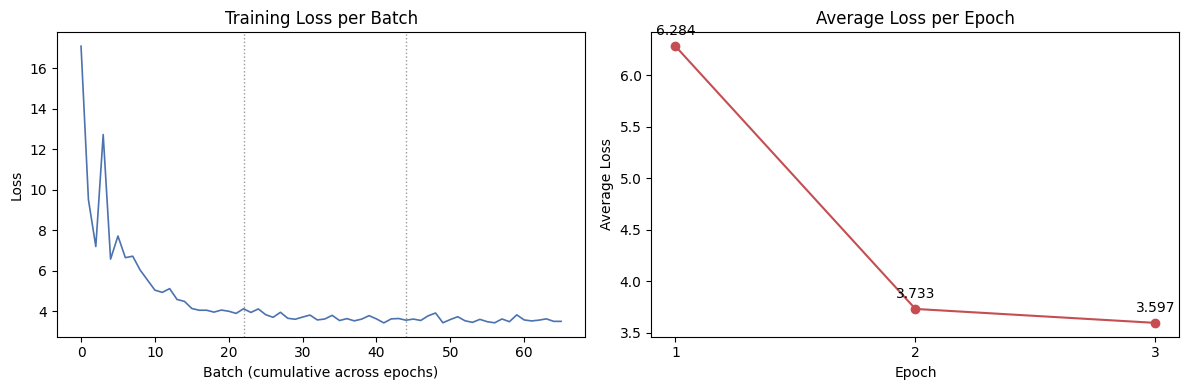

Saved to training_loss.png -- attach this for the 'screenshot of training output' requirement.


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color="#4C72B0", linewidth=1.2)
batches_per_epoch = len(train_loader)
for e in range(1, NUM_EPOCHS):
    axes[0].axvline(e * batches_per_epoch, color="#999999", linestyle=":", linewidth=1)
axes[0].set_title("Training Loss per Batch")
axes[0].set_xlabel("Batch (cumulative across epochs)")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, NUM_EPOCHS + 1), epoch_avg_losses, marker="o", color="#C44E52")
axes[1].set_title("Average Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Average Loss")
axes[1].set_xticks(range(1, NUM_EPOCHS + 1))
for i, v in enumerate(epoch_avg_losses):
    axes[1].annotate(f"{v:.3f}", (i + 1, v), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Saved to training_loss.png -- attach this for the 'screenshot of training output' requirement.")

## Step 3: Evaluate Your Model

After training, this tests the model on images it has never seen — the test split from above. `model.eval()` turns off weight updates during this step.

Beyond the handout's exact-match accuracy, this also reports **Character Error Rate (CER)** and **Word Error Rate (WER)** — exact-match is strict (one wrong character anywhere in the line counts as fully wrong), while CER/WER are the standard OCR metrics and give a more graded sense of how close predictions are.

In [9]:
import jiwer

model.eval()
print("=== Model Evaluation on Test Images ===\n")

results = []
with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id  # undo the training-time mask for decoding

        generated_ids = model.generate(pixel_values, max_length=MAX_LENGTH)
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)
        actual_text = processor.batch_decode(labels, skip_special_tokens=True)

        for pred, actual in zip(generated_text, actual_text):
            pred, actual = pred.strip(), actual.strip()
            results.append({
                "predicted": pred,
                "actual": actual,
                "exact_match": pred == actual,
                "cer": jiwer.cer(actual, pred) if actual else None,
            })
            print(f"Predicted: {pred}")
            print(f"Actual: {actual}")
            print()

correct = sum(r["exact_match"] for r in results)
total = len(results)
accuracy = (correct / total) * 100 if total > 0 else 0

refs = [r["actual"] for r in results]
hyps = [r["predicted"] for r in results]
overall_cer = jiwer.cer(refs, hyps) if refs else float("nan")
overall_wer = jiwer.wer(refs, hyps) if refs else float("nan")

print(f"Accuracy: {accuracy:.1f}% ({correct}/{total} correct)")
print(f"Character Error Rate (CER): {overall_cer:.3f}")
print(f"Word Error Rate (WER): {overall_wer:.3f}")

=== Model Evaluation on Test Images ===

Predicted: �������������������������������������������������������������������������������������������������������������������������������
Actual: منہ کی بدبو کی وجہ اور اس کا علاج

Predicted: �������������������������������������������������������������������������������������������������������������������������������
Actual: ویٹ لفٹنگ فیڈریشن پر ایڈہاک لگانے کا مطالبہ

Predicted: �������������������������������������������������������������������������������������������������������������������������������
Actual: کرکٹررومان رئیس رشتہ ازدواج میں منسلک ہو گئے

Predicted: �������������������������������������������������������������������������������������������������������������������������������
Actual: کرکٹ کے لیے حنیف محمدکی خدمات انمول ہیں، آئی سی سی چیف

Predicted: �������������������������������������������������������������������������������������������������������������������������������
Actual: پاکستان نے بھارت سے ہار کا غصہ بنگلہ دیش 

### Step 3 Extra: Automatically Find the Worst Predictions

*(Not in the handout.)* The handout asks you to note 3-5 examples where the model got it wrong for Week 5. This pulls the worst ones by CER automatically instead of scrolling through the printed output above by hand.

In [10]:
print("=== Examples where the model got it wrong (for your Week 5 discussion points) ===\n")

wrong = [r for r in results if not r["exact_match"]]
wrong_sorted = sorted(wrong, key=lambda r: (r["cer"] if r["cer"] is not None else 0), reverse=True)

if not wrong_sorted:
    print("No mistakes on the test set (or the test set is very small -- check the count above).")
else:
    for i, r in enumerate(wrong_sorted[:5], 1):
        print(f"{i}. Predicted: {r['predicted']}")
        print(f"   Actual:    {r['actual']}")
        print(f"   CER: {r['cer']:.3f}" if r["cer"] is not None else "   CER: n/a")
        print()

=== Examples where the model got it wrong (for your Week 5 discussion points) ===

1. Predicted: �������������������������������������������������������������������������������������������������������������������������������
   Actual:    لارڈز سے لارڈز تک
   CER: 7.471

2. Predicted: �������������������������������������������������������������������������������������������������������������������������������
   Actual:    منہ کی بدبو کی وجہ اور اس کا علاج
   CER: 3.848

3. Predicted: �������������������������������������������������������������������������������������������������������������������������������
   Actual:    زمبابوے کی سری لنکا کے خلاف تاریخی فتح
   CER: 3.342

4. Predicted: �������������������������������������������������������������������������������������������������������������������������������
   Actual:    ویٹ لفٹنگ فیڈریشن پر ایڈہاک لگانے کا مطالبہ
   CER: 2.953

5. Predicted: ������������������������������������������������������������������������������������

### Step 3 Extra: Visualize Sample Predictions

*(Not in the handout.)* A grid of actual test images next to what the model predicted vs. the ground truth — green border for an exact match, red for a mismatch.

Downloaded Urdu Nastaliq font to fonts/NotoNastaliqUrdu.ttf


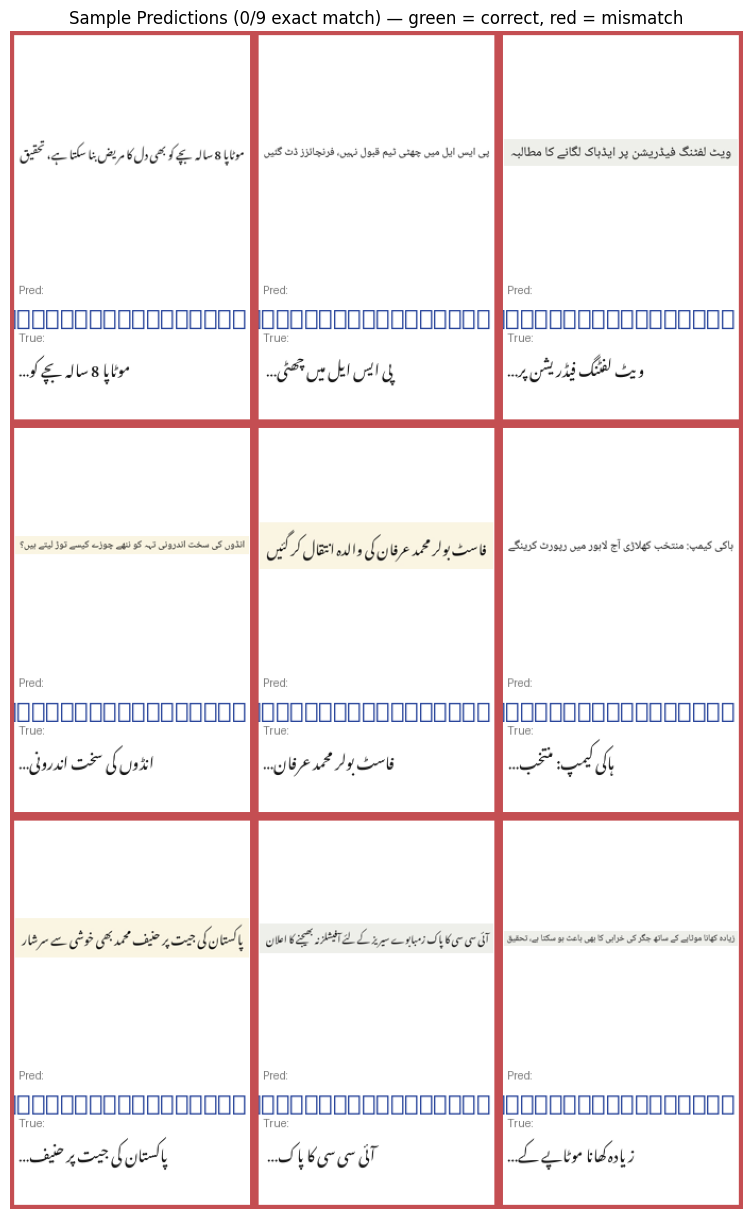

In [11]:
import textwrap
import random
from PIL import ImageDraw, ImageFont

# Map results back to their source image paths. test_loader has shuffle=False, so it
# iterates test_dataset in the same order as test_dataset.indices -- verified in testing.
test_image_paths = [test_dataset.dataset.data.iloc[i]["image"] for i in test_dataset.indices]
assert len(results) == len(test_image_paths), (
    f"Got {len(results)} predictions but {len(test_image_paths)} test images -- "
    "re-run the evaluation cell above before this one."
)
for r, img_path in zip(results, test_image_paths):
    r["image"] = img_path


import urllib.request

# The caption font (Urdu Nastaliq) isn't bundled with this notebook -- download it once
# so the fallback font_path below (used since no Week-3 FONTS dict is in memory here)
# actually points at a real file instead of a path that was never created.
os.makedirs("fonts", exist_ok=True)
NASTALIQ_FONT_PATH = "fonts/NotoNastaliqUrdu.ttf"
if not os.path.isfile(NASTALIQ_FONT_PATH):
    FONT_URL = (
        "https://raw.githubusercontent.com/google/fonts/main/"
        "ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf"
    )
    urllib.request.urlretrieve(FONT_URL, NASTALIQ_FONT_PATH)
    print(f"Downloaded Urdu Nastaliq font to {NASTALIQ_FONT_PATH}")


def show_prediction_grid(results, data_dir, n=9, cols=3, seed=0,
                          font_path=FONTS["nastaliq"] if "FONTS" in dir() else "fonts/NotoNastaliqUrdu.ttf",
                          thumb_size=230, caption_h=140, font_size=15):
    """Grid of sample test predictions: image + predicted vs. actual text.

    Captions are drawn with PIL using RTL shaping (direction='rtl', language='ur'),
    the same approach used for the Week 3 dataset-sample grid, since matplotlib
    cannot shape Arabic-script text on its own.
    """
    if not results:
        print("No results to show.")
        return
    random.seed(seed)
    sample = random.sample(results, k=min(n, len(results)))

    n_cols = min(cols, len(sample))
    n_rows = -(-len(sample) // n_cols)
    cell_w, cell_h = thumb_size, thumb_size + caption_h
    row_h = int(font_size * 2.1)

    grid_img = Image.new("RGB", (n_cols * cell_w, n_rows * cell_h), (255, 255, 255))
    font = ImageFont.truetype(font_path, font_size)
    label_font = ImageFont.load_default()

    for i, r in enumerate(sample):
        row_c, col_c = divmod(i, n_cols)
        thumb = Image.open(os.path.join(data_dir, r["image"])).convert("RGB")
        thumb.thumbnail((thumb_size - 10, thumb_size - 10))
        cell = Image.new("RGB", (cell_w, cell_h), (255, 255, 255))
        cell.paste(thumb, ((cell_w - thumb.width) // 2, (thumb_size - thumb.height) // 2))

        draw = ImageDraw.Draw(cell)
        y = thumb_size + 8
        for label, text, color in [("Pred:", r["predicted"], (30, 60, 150)), ("True:", r["actual"], (20, 20, 20))]:
            draw.text((8, y), label, font=label_font, fill=(120, 120, 120))
            y += 14
            wrapped = textwrap.wrap(str(text), width=22)[:1]
            line = wrapped[0] if wrapped else str(text)
            if len(str(text)) > 22:
                line = line + "…"
            bbox = draw.textbbox((0, 0), line, font=font, direction="rtl", language="ur")
            tw = bbox[2] - bbox[0]
            draw.text((min(cell_w - 8, tw + 8), y), line, font=font, fill=color,
                       direction="rtl", language="ur", anchor="ra")
            y += row_h

        border_color = (85, 168, 104) if r["exact_match"] else (196, 78, 82)
        draw.rectangle([0, 0, cell_w - 1, cell_h - 1], outline=border_color, width=4)
        grid_img.paste(cell, (col_c * cell_w, row_c * cell_h))

    plt.figure(figsize=(n_cols * 3.2, n_rows * 4.1))
    plt.imshow(grid_img)
    plt.axis("off")
    n_correct = sum(r["exact_match"] for r in sample)
    plt.title(f"Sample Predictions ({n_correct}/{len(sample)} exact match) — green = correct, red = mismatch")
    plt.tight_layout()
    plt.show()

show_prediction_grid(results, DATA_DIR, n=9)

## Step 4: Save Your Model

Colab sessions reset when closed. Saving to Google Drive means you can reload the model in Week 5 without retraining from scratch. This also saves the loss history and evaluation metrics alongside the model, so Week 5's discussion points don't depend on remembering numbers from this session.

This is separate from the per-epoch checkpoints saved during training (Step 2 Extra): those exist only as a disconnect safety net and get overwritten every epoch. This save happens once, after evaluation, and is the finished model plus its metrics — the one to actually reload in Week 5.

In [12]:
import json

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    raise RuntimeError(
        "google.colab isn't available -- this cell needs to run inside Google Colab to save to Drive."
    )

save_path = "/content/drive/MyDrive/SI26-urdu-ocr-model"
try:
    model.save_pretrained(save_path)
    processor.save_pretrained(save_path)

    metrics = {
        "accuracy_pct": accuracy,
        "cer": overall_cer,
        "wer": overall_wer,
        "loss_first_batch": loss_history[0],
        "loss_last_batch": loss_history[-1],
        "epoch_avg_losses": epoch_avg_losses,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
    }
    with open(os.path.join(save_path, "week4_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

    print(f"Model saved to Google Drive: {save_path}")
    print("You can load this model again next week without retraining")
except OSError as e:
    raise RuntimeError(f"Couldn't save to {save_path}: {e}. Check your Drive has free space and is mounted.") from e

Mounted at /content/drive
Model saved to Google Drive: /content/drive/MyDrive/SI26-urdu-ocr-model
You can load this model again next week without retraining


After running this cell, open [drive.google.com](https://drive.google.com) and confirm the `SI26-urdu-ocr-model` folder exists before closing Colab.

## Summary & Submission Checklist

- **GitHub link to this notebook** (with training + evaluation code) — push this file to your repo
- **`My model accuracy is X%`** — printed in Step 3 (`Accuracy: X% (n/m correct)`)
- **`Training loss went from X to X`** — printed at the end of the training loop cell
- **Screenshot of training output showing loss decreasing** — the Step 2 Extra chart (`training_loss.png`) covers this directly
- **3–5 wrong examples for Week 5** — auto-generated in Step 3 Extra

CER/WER, the prediction grid, and `week4_metrics.json` aren't required by the handout, but are there if useful context for Week 5's discussion.

One more thing worth flagging: the task text says to submit by Friday, July 25 — that's already past as of today (Sunday, July 26). Worth a quick check with your mentor on whether the deadline moved or that's just leftover boilerplate.